# Professional Data Analyst — Superstore 2016-2019
# Business Objective
The objective of this project is to analyze Superstore sales data
to understand:
- Sales performance
- Profitability
- Customer behavior
- Regional performance
- Product and category performance
- Discount impact on profitability
- Operational performance

The project follows an end-to-end analytical workflow:
Raw Data → Data Cleaning → Feature Engineering → EDA →
Statistical Analysis → Visualization → KPI Reporting →
Business Insights → Automated Export

# 1.Environment & Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2.Data Loading

In [2]:
DATA_PATH = Path("Sample - Superstore 2019.xls")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH.resolve()}"
    )

print(f"Dataset found: {DATA_PATH.resolve()}")

Dataset found: C:\Projects\Sample - Superstore 2019.xls


In [3]:
df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows: 9,994
Columns: 21


# 3.Dataset Inspection

In [4]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [5]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

Dataset shape:
(9994, 21)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:


Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

# 4.Data Quality & Cleaning

In [6]:
def dataset_overview(dataframe):
    overview = pd.DataFrame({
        "Column": dataframe.columns,
        "Data Type": dataframe.dtypes.astype(str),
        "Missing Values": dataframe.isna().sum(),
        "Missing %": dataframe.isna().mean() * 100,
        "Unique Values": dataframe.nunique(),
    })
    return overview.sort_values(
        by="Missing %",
        ascending=False
    )

overview = dataset_overview(df)
display(overview)

,Column,Data Type,Missing Values,Missing %,Unique Values
Postal Code,Postal Code,float64,11,0.11,630
Order ID,Order ID,str,0,0.00,5009
Order Date,Order Date,datetime64[us],0,0.00,1236
Ship Date,Ship Date,datetime64[us],0,0.00,1334
Row ID,Row ID,int64,0,0.00,9994
Ship Mode,Ship Mode,str,0,0.00,4
Customer ID,Customer ID,str,0,0.00,793
Segment,Segment,str,0,0.00,3
Customer Name,Customer Name,str,0,0.00,793
Country/Region,Country/Region,str,0,0.00,1


In [7]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,"9,994.00",NaN,NaN,NaN,"4,997.50",1.00,"2,499.25","4,997.50","7,495.75","9,994.00","2,885.16"
Order ID,9994,5009,CA-2019-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2018-04-30 10:03:51.979187,2016-01-03 00:00:00,2017-05-23 00:00:00,2018-06-26 00:00:00,2019-05-14 00:00:00,2019-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2018-05-04 09:03:29.645787,2016-01-07 00:00:00,2017-05-27 00:00:00,2018-06-29 00:00:00,2019-05-18 00:00:00,2020-01-05 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
clean_df = df.copy()

print("Working copy created.")
print(f"Rows: {clean_df.shape[0]:,}")
print(f"Columns: {clean_df.shape[1]:,}")

Working copy created.
Rows: 9,994
Columns: 21


In [10]:
missing_summary = (
    clean_df.isna().sum().to_frame("Missing Values")
)

missing_summary["Missing %"] = (
    missing_summary["Missing Values"]/ len(clean_df)* 100
)

missing_summary = (
    missing_summary[missing_summary["Missing Values"] > 0].sort_values("Missing Values", ascending=False)
)

display(missing_summary)

,Missing Values,Missing %
Postal Code,11,0.11


In [11]:
id_columns = [
    "Row ID",
    "Order ID",
    "Customer ID",
    "Product ID"
]

for column in id_columns:
    print(
        f"{column:<15} | "
        f"Unique: {clean_df[column].nunique():,} | "
        f"Duplicates: {clean_df[column].duplicated().sum():,}"
    )

Row ID          | Unique: 9,994 | Duplicates: 0
Order ID        | Unique: 5,009 | Duplicates: 4,985
Customer ID     | Unique: 793 | Duplicates: 9,201
Product ID      | Unique: 1,862 | Duplicates: 8,132


In [12]:
print("Row ID unique:", clean_df["Row ID"].is_unique)

Row ID unique: True


In [13]:
invalid_dates = clean_df[
    clean_df["Ship Date"] < clean_df["Order Date"]
]
print("Rows where Ship Date is before Order Date:",
      len(invalid_dates))

Rows where Ship Date is before Order Date: 0


In [14]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]
numeric_summary = clean_df[numeric_columns].describe().T
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"


In [15]:
print("Negative Sales:", (clean_df["Sales"] < 0).sum())
print("Negative Quantity:", (clean_df["Quantity"] < 0).sum())
print("Discount < 0:", (clean_df["Discount"] < 0).sum())
print("Discount > 1:", (clean_df["Discount"] > 1).sum())

Negative Sales: 0
Negative Quantity: 0
Discount < 0: 0
Discount > 1: 0


In [16]:
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]
for column in categorical_columns:
    print(clean_df[column].value_counts())
    print(f"\n")

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64


Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64




In [17]:
string_columns = clean_df.select_dtypes(include="str").columns
whitespace_issues = {}
for column in string_columns:
    issues = clean_df[column].astype(str).str.strip().ne(clean_df[column].astype(str)).sum()
    if issues > 0:
        whitespace_issues[column] = issues
whitespace_issues

{}

In [18]:
def iqr_outlier_summary(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    
    return {
        "Column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": len(outliers),
        "Outlier %": len(outliers) / len(dataframe) * 100
    }


In [72]:
def clean_superstore_data(dataframe):
    data = dataframe.copy()
    report = {
        "original_rows": len(data),
        "original_columns": len(data.columns),
        "duplicate_rows_removed": 0,
        "missing_postal_codes": int(data["Postal Code"].isna().sum()),
        "invalid_date_rows": 0
    }

    duplicate_count = data.duplicated().sum()
    if duplicate_count > 0:
        data = data.drop_duplicates()
        report["duplicate_rows_removed"] = int(duplicate_count)

    string_columns = data.select_dtypes(include="str").columns

    for column in string_columns:
        data[column] = data[column].str.strip()

    data["Order Date"] = pd.to_datetime(
        data["Order Date"],
        errors="coerce"
    )

    data["Ship Date"] = pd.to_datetime(
        data["Ship Date"],
        errors="coerce"
    )

    invalid_dates = data["Ship Date"] < data["Order Date"]
    report["invalid_date_rows"] = int(invalid_dates.sum())

    if report["invalid_date_rows"] > 0:
        data = data.loc[~invalid_dates].copy()

    data["Postal Code"] = data["Postal Code"].astype("Int64")
    report["final_rows"] = len(data)
    report["final_columns"] = len(data.columns)

    return data, report

In [73]:
clean_df, cleaning_report = clean_superstore_data(df)
print("Cleaning completed successfully.")
display(pd.DataFrame([cleaning_report]))

Cleaning completed successfully.


,original_rows,original_columns,duplicate_rows_removed,missing_postal_codes,invalid_date_rows,final_rows,final_columns
0,9994,21,0,11,0,9994,21


In [21]:
outlier_results = pd.DataFrame([
    iqr_outlier_summary(clean_df, column)
    for column in ["Sales", "Quantity", "Discount", "Profit"]])
display(outlier_results)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
0,Sales,17.28,209.94,192.66,-271.71,498.93,1167,11.68
1,Quantity,2.00,5.00,3.00,-2.50,9.50,170,1.70
2,Discount,0.00,0.20,0.20,-0.30,0.50,856,8.57
3,Profit,1.73,29.36,27.64,-39.72,70.82,1881,18.82


In [22]:
q1_sales = clean_df["Sales"].quantile(0.25)
q3_sales = clean_df["Sales"].quantile(0.75)

def classify_sales(sales):
    if sales < q1_sales:
        return "Low"
    elif sales <= q3_sales:
        return "Medium"
    else:
        return "High"

clean_df["Sales Performance Category"] = (clean_df["Sales"].apply(classify_sales))

In [23]:
display(clean_df["Sales Performance Category"].value_counts().to_frame("Transactions"))
display(clean_df.groupby("Sales Performance Category")["Sales"].agg(["count", "mean", "sum"]).round(2))

,Transactions
Sales Performance Category,
Medium,4998
High,2498
Low,2498


,count,mean,sum
Sales Performance Category,,,
High,2498,765.64,"1,912,578.32"
Low,2498,9.32,"23,280.17"
Medium,4998,72.30,"361,342.37"


# 5.Feature Engineering

In [24]:
def create_features(dataframe):

    data = dataframe.copy()

    data["Shipping Duration"] = (data["Ship Date"] -data["Order Date"]).dt.days
    data["Profit Margin"] = np.where(data["Sales"] != 0,(data["Profit"] / data["Sales"]) * 100,np.nan)
    data["Order Year"] = data["Order Date"].dt.year
    data["Order Month"] = data["Order Date"].dt.month
    data["Order Month Name"] = (
        data["Order Date"].dt.month_name()
    )
    data["Order Quarter"] = (
        data["Order Date"].dt.quarter
    )
    data["Order Year-Month"] = (
        data["Order Date"].dt.to_period("M")
    )

    # Sales Performance Category
    q1_sales = data["Sales"].quantile(0.25)
    q3_sales = data["Sales"].quantile(0.75)

    data["Sales Performance Category"] = np.select(
        [
            data["Sales"] < q1_sales,
            data["Sales"] <= q3_sales
        ],
        ["Low","Medium"],default="High"
    )
    return data

In [25]:
clean_df = create_features(clean_df)
print("Feature engineering completed.")
print(f"Original columns: {df.shape[1]}")
print(f"New columns: {clean_df.shape[1]}")

Feature engineering completed.
Original columns: 21
New columns: 29


In [26]:
print("Feature validation")
print("-" * 40)
print("Missing Shipping Duration:",clean_df["Shipping Duration"].isna().sum())
print("Minimum Shipping Duration:",clean_df["Shipping Duration"].min())
print("Maximum Shipping Duration:",clean_df["Shipping Duration"].max())
print("Missing Profit Margin:",clean_df["Profit Margin"].isna().sum())

Feature validation
----------------------------------------
Missing Shipping Duration: 0
Minimum Shipping Duration: 0
Maximum Shipping Duration: 7
Missing Profit Margin: 0


In [27]:
feature_columns = [
    "Order Date",
    "Ship Date",
    "Shipping Duration",
    "Sales",
    "Profit",
    "Profit Margin",
    "Order Year",
    "Order Month",
    "Order Month Name",
    "Order Quarter",
    "Order Year-Month",
    "Sales Performance Category"
]
display(clean_df[feature_columns].head(10))

,Order Date,Ship Date,Shipping Duration,Sales,Profit,Profit Margin,Order Year,Order Month,Order Month Name,Order Quarter,Order Year-Month,Sales Performance Category
0,2018-11-08,2018-11-11,3,261.96,41.91,16.00,2018,11,November,4,2018-11,High
1,2018-11-08,2018-11-11,3,731.94,219.58,30.00,2018,11,November,4,2018-11,High
2,2018-06-12,2018-06-16,4,14.62,6.87,47.00,2018,6,June,2,2018-06,Low
3,2017-10-11,2017-10-18,7,957.58,-383.03,-40.00,2017,10,October,4,2017-10,High
4,2017-10-11,2017-10-18,7,22.37,2.52,11.25,2017,10,October,4,2017-10,Medium
5,2016-06-09,2016-06-14,5,48.86,14.17,29.00,2016,6,June,2,2016-06,Medium
6,2016-06-09,2016-06-14,5,7.28,1.97,27.00,2016,6,June,2,2016-06,Low
7,2016-06-09,2016-06-14,5,907.15,90.72,10.00,2016,6,June,2,2016-06,High
8,2016-06-09,2016-06-14,5,18.50,5.78,31.25,2016,6,June,2,2016-06,Medium
9,2016-06-09,2016-06-14,5,114.90,34.47,30.00,2016,6,June,2,2016-06,Medium


In [28]:
feature_validation = pd.DataFrame({
    "Feature": feature_columns,
    "Missing Values": [
        clean_df[column].isna().sum()
        for column in feature_columns
    ],
    "Unique Values": [
        clean_df[column].nunique()
        for column in feature_columns
    ]
})
display(feature_validation)

,Feature,Missing Values,Unique Values
0,Order Date,0,1236
1,Ship Date,0,1334
2,Shipping Duration,0,8
3,Sales,0,6144
4,Profit,0,7545
5,Profit Margin,0,1152
6,Order Year,0,4
7,Order Month,0,12
8,Order Month Name,0,12
9,Order Quarter,0,4


# 6.Exploratory Data Analysis

In [29]:
numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Duration",
    "Profit Margin"
]
eda_summary = clean_df[numeric_cols].describe().T
eda_summary["Skewness"] = clean_df[numeric_cols].skew()
display(eda_summary.round(2))

,count,mean,std,min,25%,50%,75%,max,Skewness
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48",12.97
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00,1.28
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80,1.68
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98",7.56
Shipping Duration,"9,994.00",3.96,1.75,0.00,3.00,4.00,5.00,7.00,-0.42
Profit Margin,"9,994.00",12.03,46.68,-275.00,7.50,27.00,36.25,50.00,-2.89


# 7.Statistical & Business Analysis

In [30]:
category_analysis = (clean_df.groupby("Category").agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    ).sort_values("Sales", ascending=False))

category_analysis["Profit Margin %"] = (category_analysis["Profit"]/ category_analysis["Sales"]* 100)
display(category_analysis.round(2))

,Sales,Profit,Quantity,Orders,Profit Margin %
Category,,,,,
Technology,"836,154.03","145,454.95",6939,1544,17.40
Furniture,"741,999.80","18,451.27",8028,1764,2.49
Office Supplies,"719,047.03","122,490.80",22906,3742,17.04


In [31]:
region_analysis = (
    clean_df.groupby("Region").agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
)
region_analysis["Profit Margin %"] = (region_analysis["Profit"]/ region_analysis["Sales"]* 100)
region_analysis = region_analysis.sort_values(
    "Profit",
    ascending=False
)
display(region_analysis.round(2))

,Sales,Profit,Orders,Profit Margin %
Region,,,,
West,"725,457.82","108,418.45",1611,14.94
East,"678,781.24","91,522.78",1401,13.48
South,"391,721.90","46,749.43",822,11.93
Central,"501,239.89","39,706.36",1175,7.92


In [32]:
correlation_matrix = clean_df[numeric_cols].corr()
display(correlation_matrix.round(2))

,Sales,Quantity,Discount,Profit,Shipping Duration,Profit Margin
Sales,1.00,0.20,-0.03,0.48,-0.01,0.00
Quantity,0.20,1.00,0.01,0.07,0.02,-0.01
Discount,-0.03,0.01,1.00,-0.22,0.00,-0.86
Profit,0.48,0.07,-0.22,1.00,-0.00,0.22
Shipping Duration,-0.01,0.02,0.00,-0.00,1.00,-0.01
Profit Margin,0.00,-0.01,-0.86,0.22,-0.01,1.00


# 8.Data Visualization

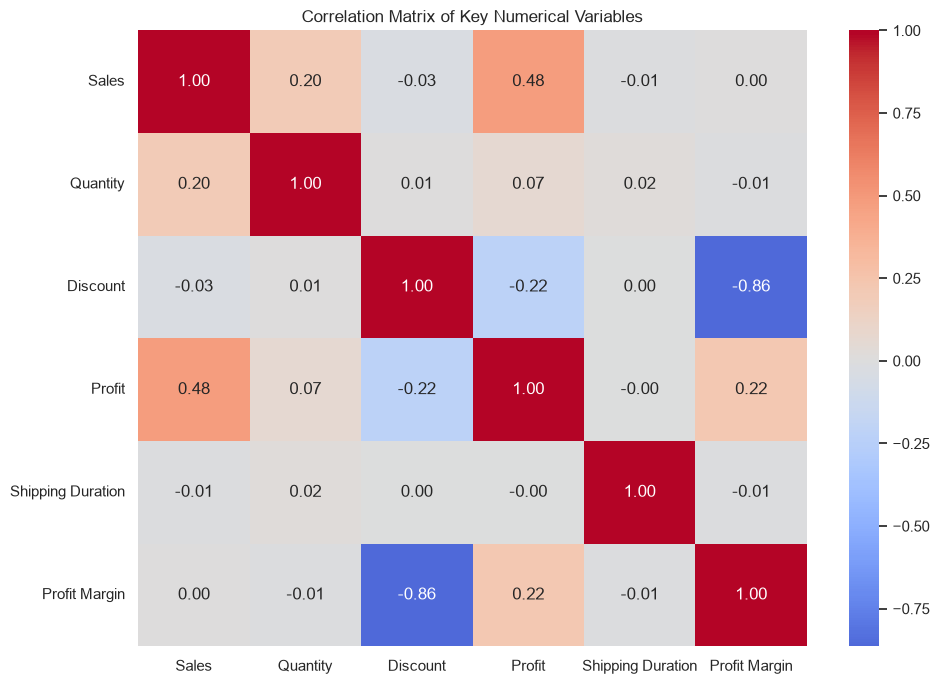

In [33]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Key Numerical Variables")
plt.tight_layout()
plt.show()

Discount vs Profit Margin is -0.86. 
Quantity barely moves profit. 
Discount policy is the profitability lever, not volume.

In [34]:
loss_transactions = clean_df[clean_df["Profit"] < 0]
loss_rate = (len(loss_transactions)/ len(clean_df)* 100)
print(f"Loss-making transactions: {len(loss_transactions):,}")
print(f"Loss-making transaction rate: {loss_rate:.2f}%")

Loss-making transactions: 1,871
Loss-making transaction rate: 18.72%


In [35]:
loss_by_category = (loss_transactions.groupby("Category").agg(
        Transactions=("Order ID", "count"),
        Total_Loss=("Profit", "sum"),
        Avg_Loss=("Profit", "mean")
    ).sort_values("Total_Loss"))
display(loss_by_category.round(2))

,Transactions,Total_Loss,Avg_Loss
Category,,,
Furniture,714,"-60,936.11",-85.34
Office Supplies,886,"-56,615.26",-63.90
Technology,271,"-38,579.92",-142.36


In [36]:
annual = (
    clean_df.groupby("Order Year")
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
)
annual["Sales YoY %"] = annual["Sales"].pct_change() * 100
annual["Profit YoY %"] = annual["Profit"].pct_change() * 100
n_years = annual.index.max() - annual.index.min()
cagr = (annual.loc[annual.index.max(), "Sales"] /
        annual.loc[annual.index.min(), "Sales"]) ** (1 / n_years) - 1
print(f"Sales CAGR {annual.index.min()}–{annual.index.max()}: {cagr:.1%}")
display(annual.round(2))

Sales CAGR 2016–2019: 14.8%


,Sales,Profit,Sales YoY %,Profit YoY %
Order Year,,,,
2016,"484,247.50","49,543.97",NaN,NaN
2017,"470,532.51","61,618.60",-2.83,24.37
2018,"609,205.60","81,795.17",29.47,32.74
2019,"733,215.26","93,439.27",20.36,14.24


In [37]:
monthly_analysis = (
    clean_df.groupby("Order Year-Month").agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Quantity=("Quantity", "sum")
    ).reset_index()
)
monthly_analysis["Profit Margin %"] = (monthly_analysis["Profit"]/ monthly_analysis["Sales"]* 100)
monthly_analysis["Order Year-Month"] = (monthly_analysis["Order Year-Month"].dt.to_timestamp())
display(
    monthly_analysis.head(12).round({
        "Sales": 2,
        "Profit": 2,
        "Orders": 2,
        "Quantity": 2,
        "Profit Margin %": 2
    })
)

,Order Year-Month,Sales,Profit,Orders,Quantity,Profit Margin %
0,2016-01-01,"14,236.90","2,450.19",32,284,17.21
1,2016-02-01,"4,519.89",862.31,28,159,19.08
2,2016-03-01,"55,691.01",498.73,71,585,0.90
3,2016-04-01,"28,295.34","3,488.84",66,536,12.33
4,2016-05-01,"23,648.29","2,738.71",69,466,11.58
5,2016-06-01,"34,595.13","4,976.52",66,521,14.39
6,2016-07-01,"33,946.39",-841.48,65,550,-2.48
7,2016-08-01,"27,909.47","5,318.10",72,609,19.05
8,2016-09-01,"81,777.35","8,328.10",130,1000,10.18
9,2016-10-01,"31,453.39","3,448.26",78,573,10.96


In [38]:
subcategory_analysis = (
    clean_df.groupby("Sub-Category").agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
)
subcategory_analysis["Profit Margin %"] = (subcategory_analysis["Profit"]/ subcategory_analysis["Sales"]* 100)

subcategory_analysis = subcategory_analysis.sort_values("Profit",ascending=False)

display(subcategory_analysis.round(2))

,Sales,Profit,Quantity,Orders,Profit Margin %
Sub-Category,,,,,
Copiers,"149,528.03","55,617.82",234,68,37.20
Phones,"330,007.05","44,515.73",3289,814,13.49
Accessories,"167,380.32","41,936.64",2976,718,25.05
Paper,"78,479.21","34,053.57",5178,1191,43.39
Binders,"203,412.73","30,221.76",5974,1316,14.86
Chairs,"328,449.10","26,590.17",2356,576,8.10
Storage,"223,843.61","21,278.83",3158,777,9.51
Appliances,"107,532.16","18,138.01",1729,451,16.87
Furnishings,"91,705.16","13,059.14",3563,877,14.24


In [39]:
discount_analysis = (
    clean_df.groupby("Discount").agg(
        Transactions=("Order ID", "count"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Average_Profit=("Profit", "mean")
    )
)
discount_analysis["Profit Margin %"] = (discount_analysis["Profit"]/ discount_analysis["Sales"]* 100)
display(discount_analysis.round(2))

,Transactions,Sales,Profit,Average_Profit,Profit Margin %
Discount,,,,,
0.00,4798,"1,087,908.47","320,987.60",66.90,29.51
0.10,94,"54,369.35","9,029.18",96.06,16.61
0.15,52,"27,558.52","1,418.99",27.29,5.15
0.20,3657,"764,594.37","90,337.31",24.70,11.82
0.30,227,"103,226.66","-10,369.28",-45.68,-10.05
0.32,27,"14,493.46","-2,391.14",-88.56,-16.50
0.40,206,"116,417.78","-23,057.05",-111.93,-19.81
0.45,11,"5,484.97","-2,493.11",-226.65,-45.45
0.50,66,"58,918.54","-20,506.43",-310.70,-34.80


In [40]:
loss_rate_by_discount = (
    clean_df.groupby("Discount").agg(
        Transactions=("Profit", "size"),
        Loss_Making=("Profit", lambda x: (x < 0).sum())
    )
)
loss_rate_by_discount["Loss Rate %"] = (loss_rate_by_discount["Loss_Making"]/loss_rate_by_discount["Transactions"]* 100)
display(loss_rate_by_discount.round(2))

,Transactions,Loss_Making,Loss Rate %
Discount,,,
0.00,4798,0,0.00
0.10,94,4,4.26
0.15,52,17,32.69
0.20,3657,502,13.73
0.30,227,208,91.63
0.32,27,27,100.00
0.40,206,180,87.38
0.45,11,11,100.00
0.50,66,66,100.00


In [41]:
correlation_pairs = (
    correlation_matrix.where( np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool)).stack().reset_index()
)
correlation_pairs.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]
correlation_pairs = correlation_pairs.dropna(
    subset=["Correlation"]
)
correlation_pairs["Absolute Correlation"] = (
    correlation_pairs["Correlation"].abs()
)
correlation_pairs = correlation_pairs.sort_values("Absolute Correlation", ascending=False)
display(correlation_pairs.round(2))

,Variable 1,Variable 2,Correlation,Absolute Correlation
17,Discount,Profit Margin,-0.86,0.86
3,Sales,Profit,0.48,0.48
23,Profit,Profit Margin,0.22,0.22
15,Discount,Profit,-0.22,0.22
1,Sales,Quantity,0.20,0.20
9,Quantity,Profit,0.07,0.07
2,Sales,Discount,-0.03,0.03
10,Quantity,Shipping Duration,0.02,0.02
29,Shipping Duration,Profit Margin,-0.01,0.01
8,Quantity,Discount,0.01,0.01


In [42]:
best_region = region_analysis["Profit"].idxmax()
worst_region = region_analysis["Profit Margin %"].idxmin()
best_category = category_analysis["Profit"].idxmax()
worst_category = category_analysis["Profit Margin %"].idxmin()
most_loss_category = loss_by_category["Total_Loss"].idxmin()

print("BUSINESS FINDINGS")
print("=" * 50)
print(
    f"Most profitable region: {best_region} "
    f"(${region_analysis.loc[best_region, 'Profit']:,.2f})"
)
print(
    f"Lowest-margin region: {worst_region} "
    f"({region_analysis.loc[worst_region, 'Profit Margin %']:.2f}%)"
)
print(
    f"Most profitable category: {best_category} "
    f"(${category_analysis.loc[best_category, 'Profit']:,.2f})"
)
print(
    f"Lowest-margin category: {worst_category} "
    f"({category_analysis.loc[worst_category, 'Profit Margin %']:.2f}%)"
)
print(
    f"Category with largest total loss: "
    f"{most_loss_category}"
)

BUSINESS FINDINGS
Most profitable region: West ($108,418.45)
Lowest-margin region: Central (7.92%)
Most profitable category: Technology ($145,454.95)
Lowest-margin category: Furniture (2.49%)
Category with largest total loss: Furniture


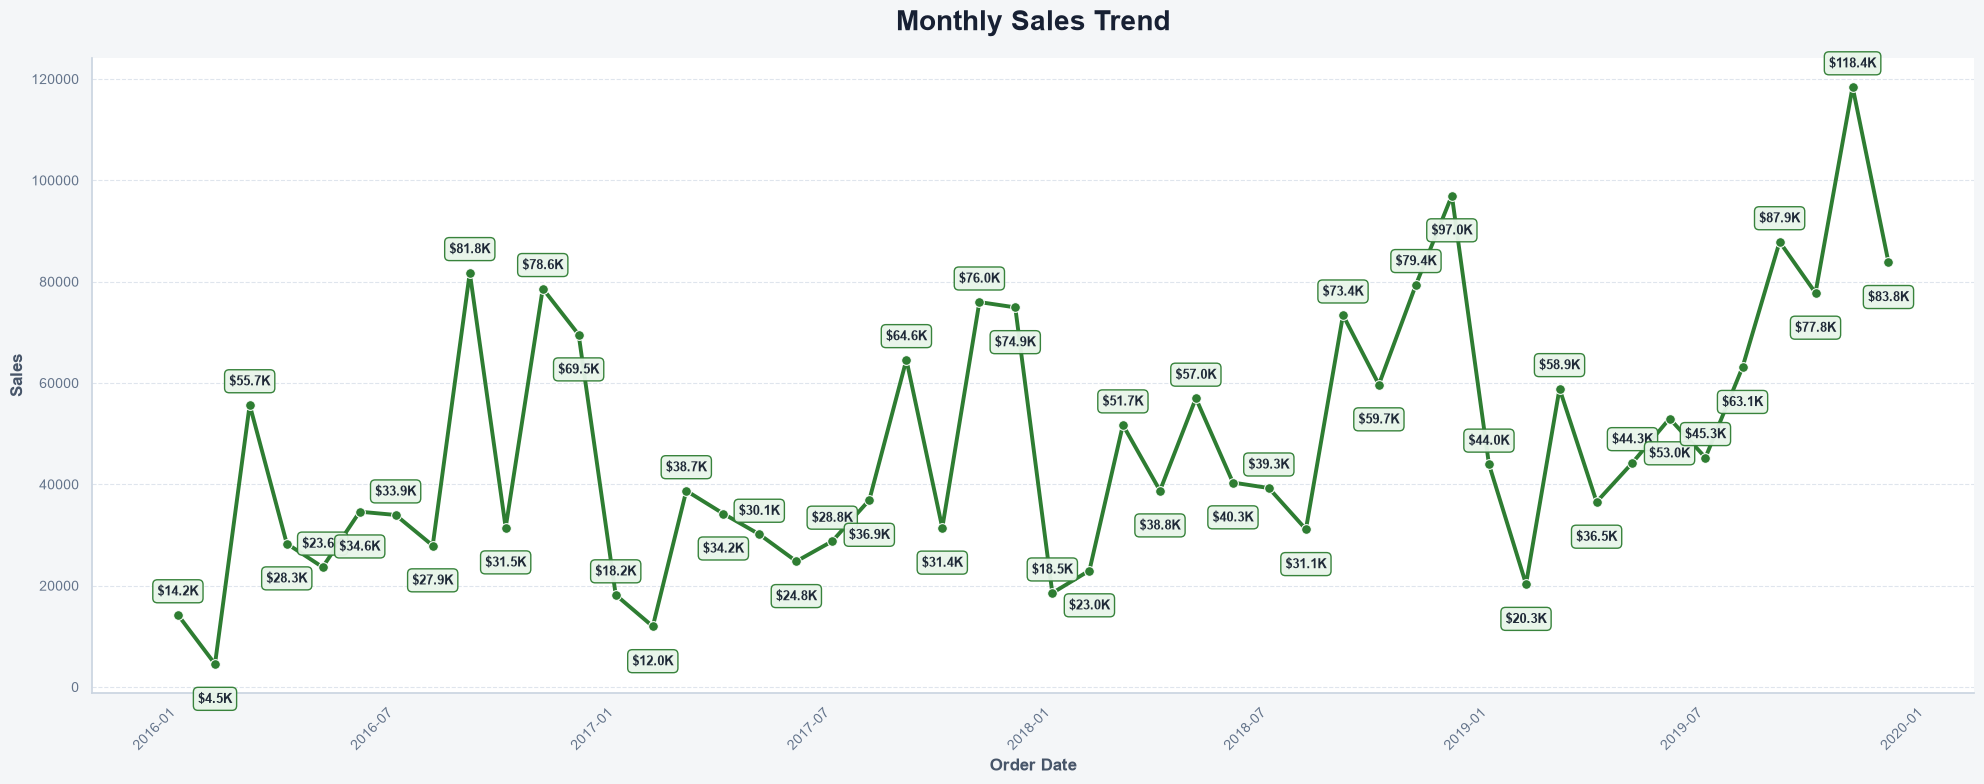

In [43]:
plt.figure(figsize=(20, 8))

ax = sns.lineplot(
    data=monthly_analysis,
    x="Order Year-Month",
    y="Sales",
    marker="o",
    linewidth=2.8,
    color="#2E7D32",
    markersize=7
)

ax.set_facecolor("#FFFFFF")
plt.gcf().set_facecolor("#F4F6F8")

def format_value(value):
    if abs(value) >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        return f"${value / 1_000:.1f}K"
    else:
        return f"${value:.0f}"

for i, (x, y) in enumerate(
    zip(
        monthly_analysis["Order Year-Month"],
        monthly_analysis["Sales"]
    )
):

    offset = 14 if i % 2 == 0 else -28

    ax.annotate(
        format_value(y),
        (x, y),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        fontsize=9.5,
        fontweight="bold",
        color="#1F2937",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="#E8F5E9",
            edgecolor="#2E7D32",
            linewidth=1,
            alpha=0.95
        )
    )


plt.title(
    "Monthly Sales Trend",
    fontsize=20,
    fontweight="bold",
    color="#172033",
    pad=20
)

plt.xlabel(
    "Order Date",
    fontsize=12,
    fontweight="bold",
    color="#475569"
)

plt.ylabel(
    "Sales",
    fontsize=12,
    fontweight="bold",
    color="#475569"
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10,
    color="#64748B"
)

plt.yticks(
    fontsize=10,
    color="#64748B"
)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    color="#CBD5E1",
    alpha=0.6
)

plt.grid(
    axis="x",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")
ax.spines["bottom"].set_color("#CBD5E1")

plt.tight_layout()

plt.show()

    Key insight: Sales showed a clear upward trend across the analyzed period, highlighting overall business growth while also revealing seasonal fluctuations

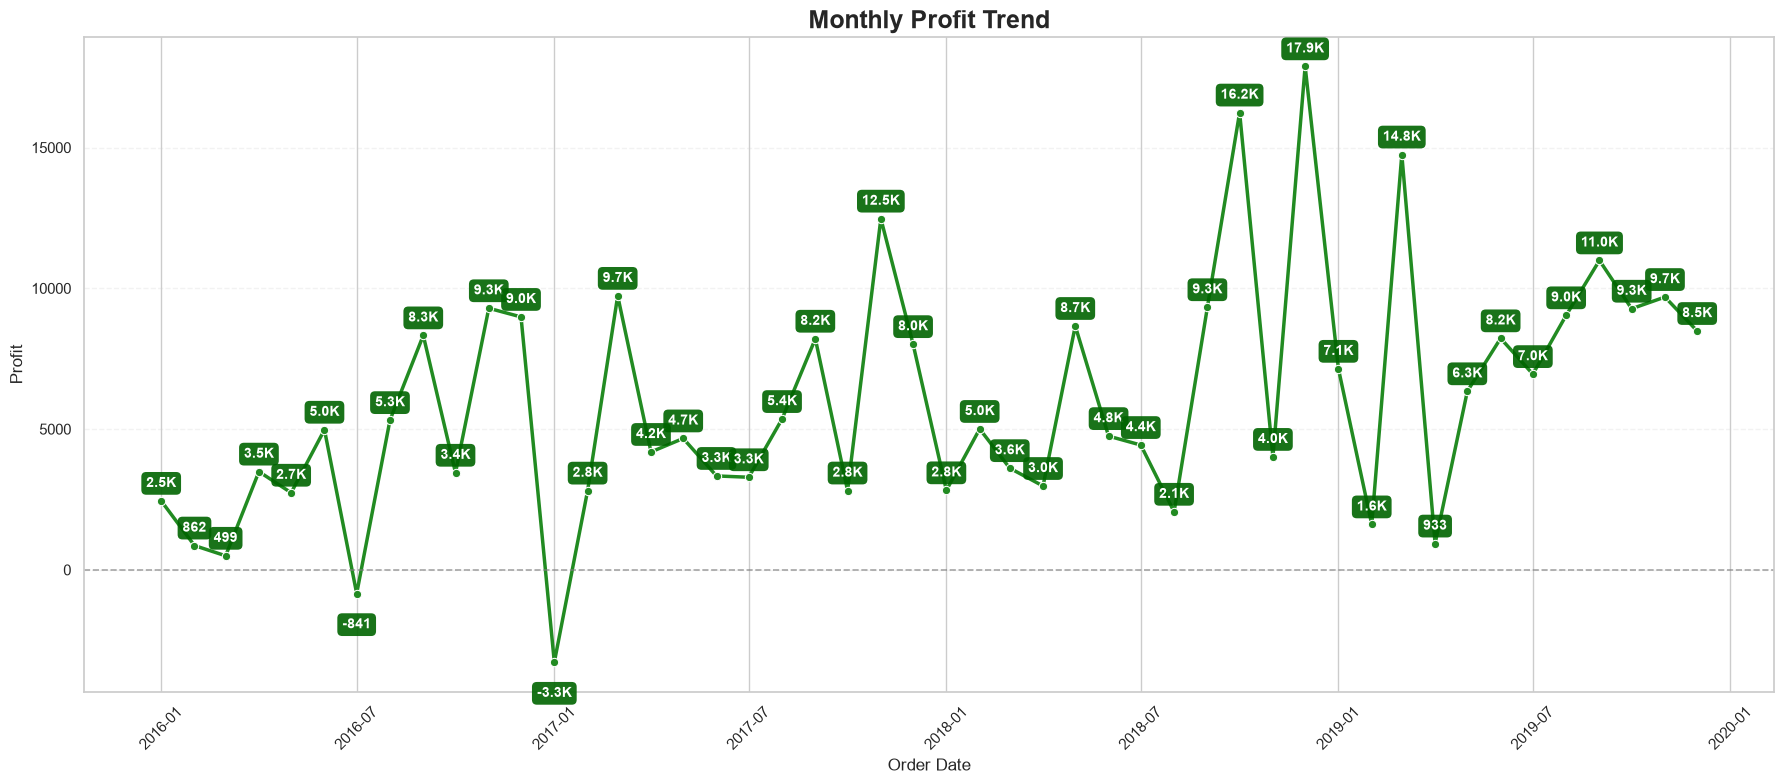

In [44]:
plt.figure(figsize=(18, 8))

ax = sns.lineplot(
    data=monthly_analysis,
    x="Order Year-Month",
    y="Profit",
    marker="o",
    linewidth=2.5,
    color="forestgreen"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="gray",
    alpha=0.7
)

def format_value(value):
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        return f"{value / 1_000:.1f}K"
    else:
        return f"{value:.0f}"


for x, y in zip(
    monthly_analysis["Order Year-Month"],
    monthly_analysis["Profit"]
):
    ax.annotate(
        format_value(y),
        (x, y),
        xytext=(0, 10 if y >= 0 else -25),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="darkgreen",
            edgecolor="none",
            alpha=0.9
        )
    )


plt.title(
    "Monthly Profit Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Order Date", fontsize=12)
plt.ylabel("Profit", fontsize=12)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)
bbox=dict(
    boxstyle="round,pad=0.35",
    facecolor="lightgreen",
    edgecolor="forestgreen",
    linewidth=1
),
color="black"
plt.tight_layout()
plt.show()

Profit does not track sales 1:1. Some high-sales months are weak on profit — that is discount/mix, not demand.

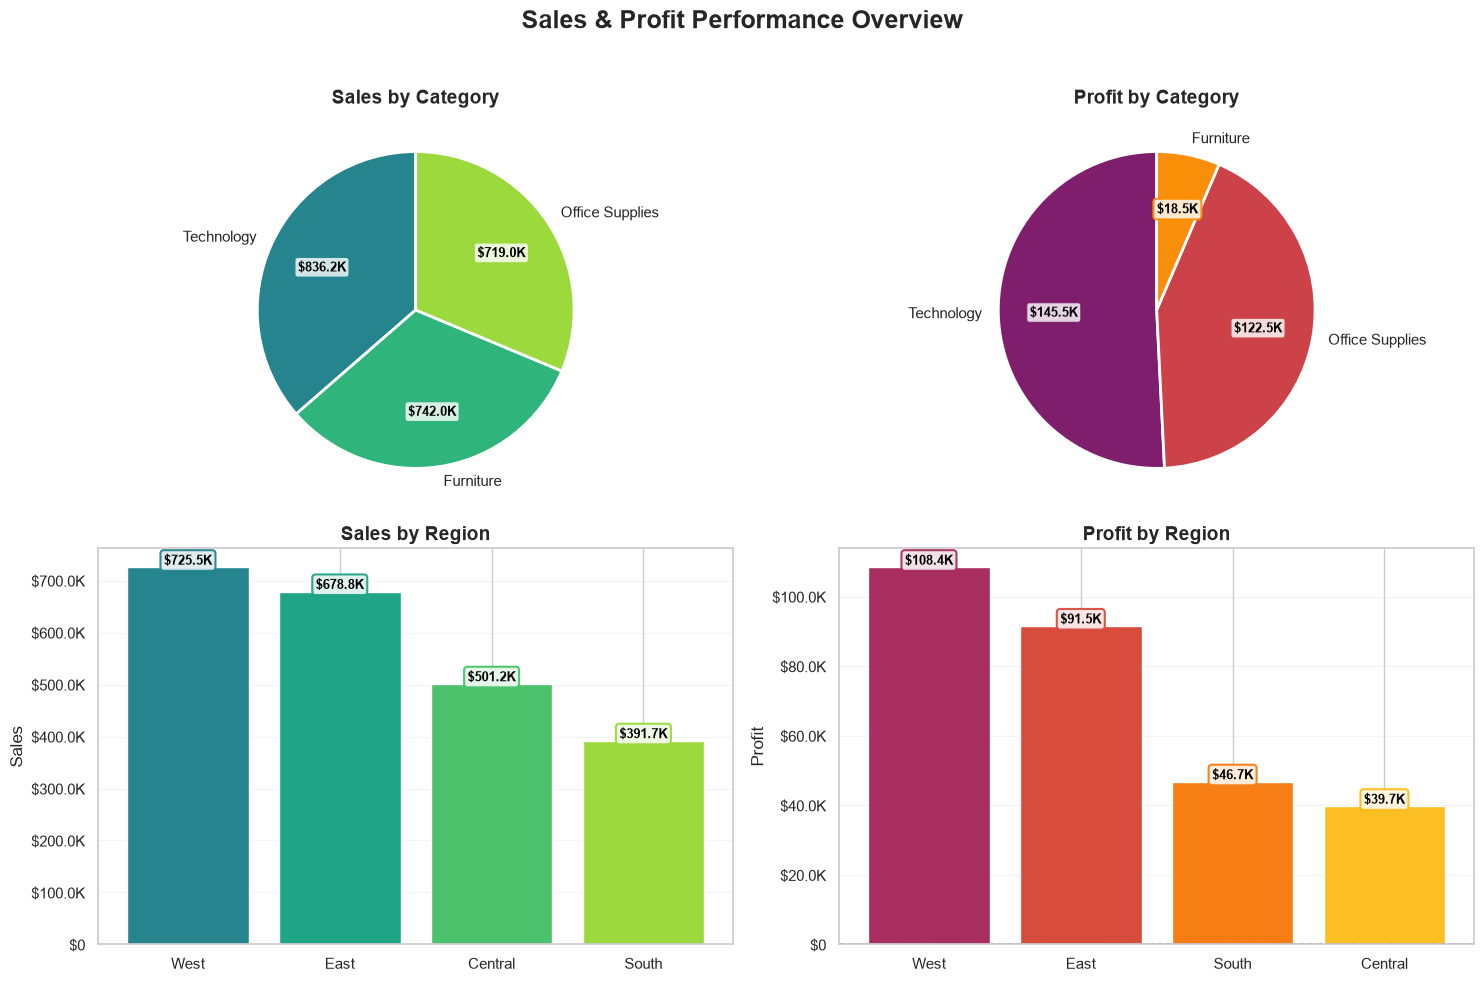

In [45]:
from matplotlib.ticker import FuncFormatter


def format_money(value, pos=None):

    abs_value = abs(value)

    if abs_value >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"

    elif abs_value >= 1_000:
        return f"${value / 1_000:.1f}K"

    else:
        return f"${value:,.0f}"


def light_color(color, amount=0.85):

    color = np.array(color[:3])

    return tuple(
        color * (1 - amount) + np.ones(3) * amount
    )

category_sales = (
    clean_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_profit = (
    clean_df
    .groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

region_sales = (
    clean_df
    .groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_profit = (
    clean_df
    .groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

sales_colors = plt.cm.viridis(
    np.linspace(
        0.45,
        0.85,
        len(category_sales)
    )
)

wedges1, texts1 = axes[0, 0].pie(
    category_sales.values,
    labels=category_sales.index,
    colors=sales_colors,
    startangle=90,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=2
    )
)

axes[0, 0].set_title(
    "Sales by Category",
    fontsize=14,
    fontweight="bold"
)

for wedge, value in zip(
    wedges1,
    category_sales.values
):

    angle = (
        wedge.theta1 + wedge.theta2
    ) / 2

    x = 0.65 * np.cos(
        np.radians(angle)
    )

    y = 0.65 * np.sin(
        np.radians(angle)
    )

    slice_color = wedge.get_facecolor()

    axes[0, 0].text(
        x,
        y,
        format_money(value),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor=light_color(slice_color),
            edgecolor=slice_color,
            linewidth=1.5,
            alpha=0.95
        )
    )

profit_colors = plt.cm.inferno(
    np.linspace(
        0.35,
        0.75,
        len(category_profit)
    )
)

wedges2, texts2 = axes[0, 1].pie(
    category_profit.values,
    labels=category_profit.index,
    colors=profit_colors,
    startangle=90,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=2
    )
)

axes[0, 1].set_title(
    "Profit by Category",
    fontsize=14,
    fontweight="bold"
)

for wedge, value in zip(
    wedges2,
    category_profit.values
):

    angle = (wedge.theta1 + wedge.theta2)/ 2
    x = 0.65 * np.cos(
        np.radians(angle)
    )
    y = 0.65 * np.sin(
        np.radians(angle)
    )

    slice_color = wedge.get_facecolor()

    axes[0, 1].text(
        x,
        y,
        format_money(value),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor=light_color(slice_color),
            edgecolor=slice_color,
            linewidth=1.5,
            alpha=0.95
        )
    )


sales_region_colors = plt.cm.viridis(
    np.linspace(
        0.45,
        0.85,
        len(region_sales)
    )
)

bars3 = axes[1, 0].bar(
    region_sales.index,
    region_sales.values,
    color=sales_region_colors
)

axes[1, 0].set_title(
    "Sales by Region",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Sales")

axes[1, 0].yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

axes[1, 0].grid(
    axis="y",
    alpha=0.2
)

for bar, value in zip(
    bars3,
    region_sales.values
):

    bar_color = bar.get_facecolor()

    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        format_money(value),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor=light_color(bar_color),
            edgecolor=bar_color,
            linewidth=1.5,
            alpha=0.95
        )
    )

profit_region_colors = plt.cm.inferno(
    np.linspace(
        0.45,
        0.85,
        len(region_profit)
    )
)

bars4 = axes[1, 1].bar(
    region_profit.index,
    region_profit.values,
    color=profit_region_colors
)

axes[1, 1].set_title(
    "Profit by Region",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

axes[1, 1].axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="#8B1E3F",
    alpha=0.8
)

axes[1, 1].grid(
    axis="y",
    alpha=0.2
)

for bar, value in zip(
    bars4,
    region_profit.values
):

    
    bar_color = bar.get_facecolor()
    if value >= 0:

        y_position = value
        va = "bottom"

    else:

        y_position = value
        va = "top"

    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        format_money(value),
        ha="center",
        va=va,
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor=light_color(bar_color),
            edgecolor=bar_color,
            linewidth=1.5,
            alpha=0.95
        )
    )

fig.suptitle(
    "Sales & Profit Performance Overview",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

Technology leads profit; Furniture is near break-even despite solid sales. West leads profit; Central is the margin problem.

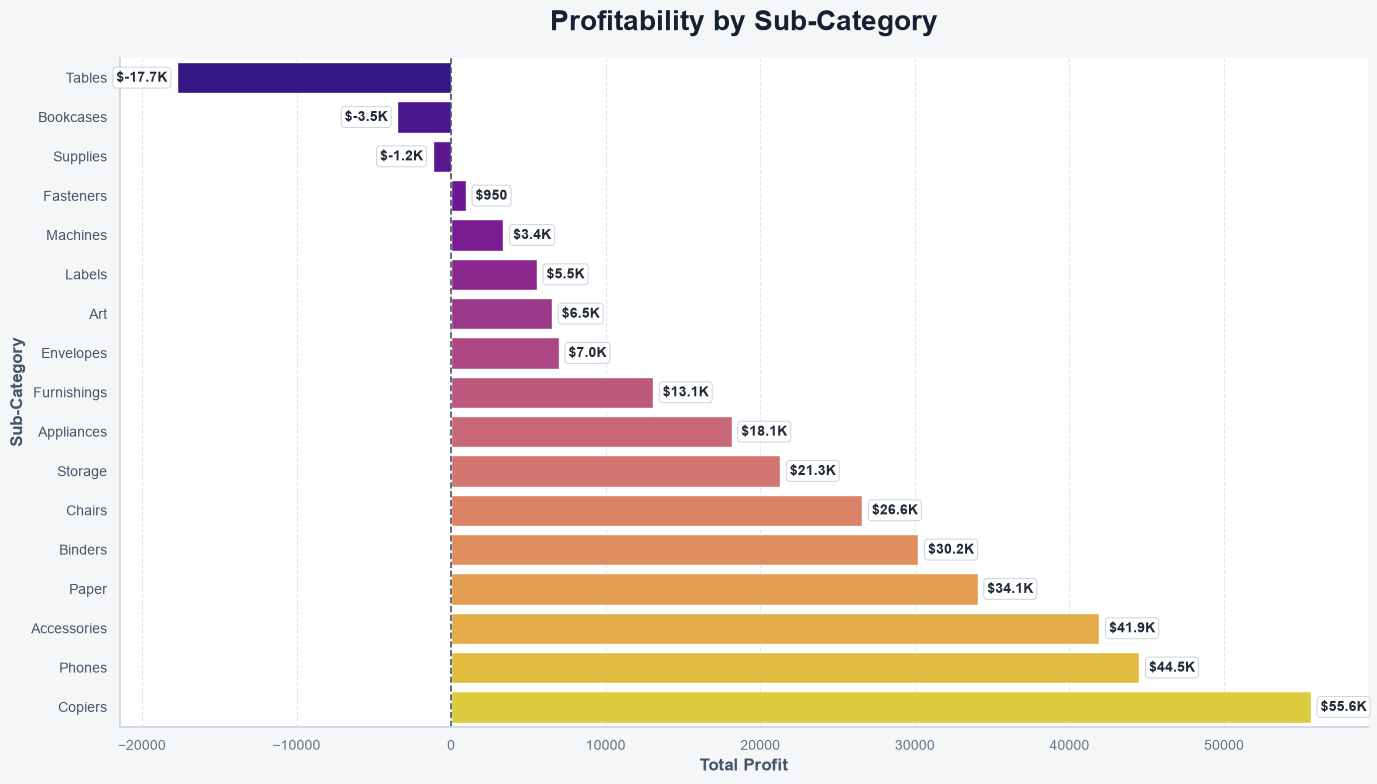

In [46]:
subcategory_profit = (
    clean_df
    .groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    x=subcategory_profit.values,
    y=subcategory_profit.index,
    hue=subcategory_profit.index,
    palette="plasma",
    legend=False
)

ax.set_facecolor("#FFFFFF")
plt.gcf().set_facecolor("#F4F6F8")

plt.axvline(
    0,
    color="#475569",
    linestyle="--",
    linewidth=1.2
)

def format_profit(value):

    if abs(value) >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"

    elif abs(value) >= 1_000:
        return f"${value / 1_000:.1f}K"

    else:
        return f"${value:.0f}"

max_profit = subcategory_profit.abs().max()

for i, value in enumerate(subcategory_profit.values):

    if value >= 0:

        ax.annotate(
            format_profit(value),
            (value, i),
            xytext=(7, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#1F2937",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="#FFFFFF",
                edgecolor="#D1D5DB",
                linewidth=0.8,
                alpha=0.95
            )
        )

    else:

        ax.annotate(
            format_profit(value),
            (value, i),
            xytext=(-7, 0),
            textcoords="offset points",
            ha="right",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#1F2937",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="#FFFFFF",
                edgecolor="#D1D5DB",
                linewidth=0.8,
                alpha=0.95
            )
        )


plt.title(
    "Profitability by Sub-Category",
    fontsize=20,
    fontweight="bold",
    color="#172033",
    pad=20
)


plt.xlabel(
    "Total Profit",
    fontsize=12,
    fontweight="bold",
    color="#475569"
)

plt.ylabel(
    "Sub-Category",
    fontsize=12,
    fontweight="bold",
    color="#475569"
)

plt.xticks(
    fontsize=10,
    color="#64748B"
)

plt.yticks(
    fontsize=10,
    color="#475569"
)

plt.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    color="#CBD5E1",
    alpha=0.55
)

plt.grid(
    axis="y",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")
ax.spines["bottom"].set_color("#CBD5E1")

plt.tight_layout()
plt.show()

Tables and Bookcases are the Furniture hole. Chairs/Furnishings are not the issue. Do not “fix Furniture”; fix those two lines.

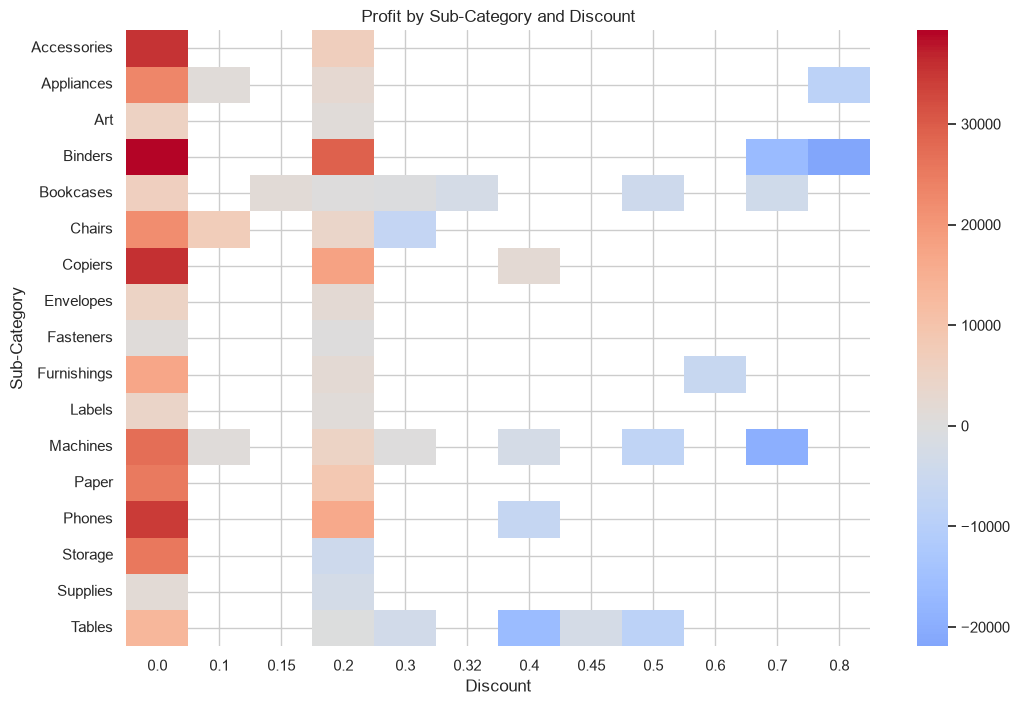

In [47]:
heat = (
    clean_df.assign(Discount=clean_df["Discount"].round(2))
    .pivot_table(index="Sub-Category", columns="Discount",
                 values="Profit", aggfunc="sum")
)
plt.figure(figsize=(12, 8))
sns.heatmap(heat, center=0, cmap="coolwarm")
plt.title("Profit by Sub-Category and Discount")
plt.show()

Tables/Bookcases stay negative even at moderate discounts. Binders blow up at 0.70–0.80. Policy should be by sub-category, not a store-wide %.

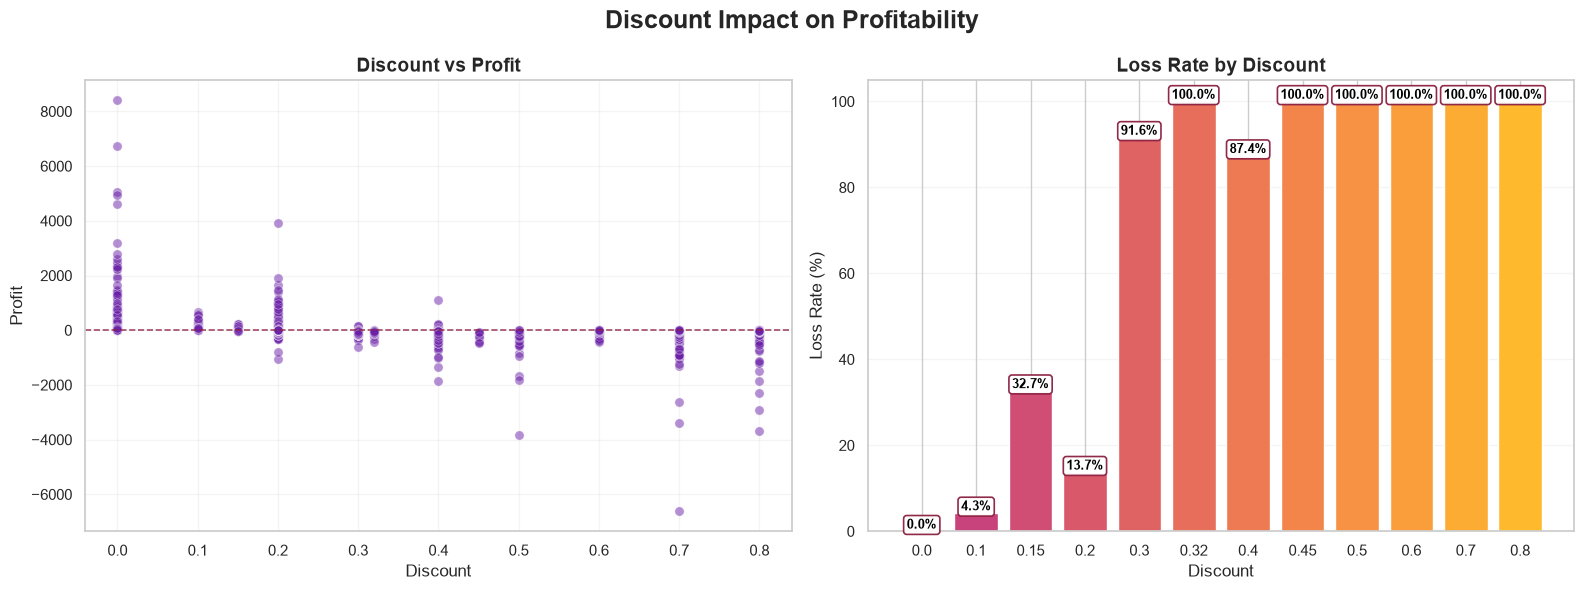

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=clean_df,
    x="Discount",
    y="Profit",
    alpha=0.5,
    color="#6B21A8",
    s=45,
    ax=axes[0]
)

axes[0].axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="#8B1E3F",
    alpha=0.8
)

axes[0].set_title(
    "Discount vs Profit",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Discount")
axes[0].set_ylabel("Profit")

axes[0].grid(
    alpha=0.2
)

loss_data = loss_rate_by_discount.reset_index()

bars = axes[1].bar(
    loss_data["Discount"].astype(str),
    loss_data["Loss Rate %"],
    color=plt.cm.plasma(
        np.linspace(0.45, 0.85, len(loss_data))
    )
)

axes[1].set_title(
    "Loss Rate by Discount",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Discount")
axes[1].set_ylabel("Loss Rate (%)")
axes[1].grid(
    axis="y",
    alpha=0.2
)

for bar, value in zip(bars, loss_data["Loss Rate %"]):

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="#8B1E3F",
            linewidth=1.2,
            alpha=0.95
        )
    )


fig.suptitle(
    "Discount Impact on Profitability",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Loss rate explodes once discount ≥ 0.30 (often ~100%). 20% is already a danger zone.

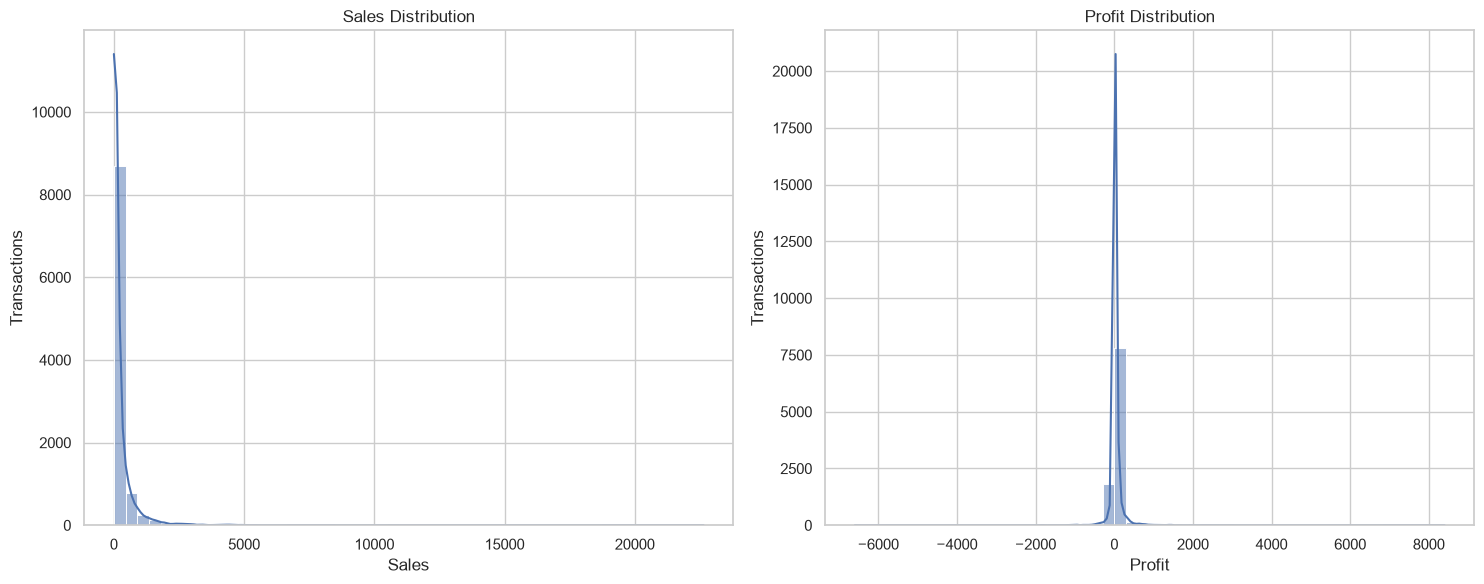

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(
    clean_df["Sales"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Transactions")

sns.histplot(
    clean_df["Profit"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Profit Distribution")
axes[1].set_xlabel("Profit")
axes[1].set_ylabel("Transactions")

plt.tight_layout()
plt.show()

Sales are extremely right-skewed. A few large orders dominate totals. Replot Sales on a log x-axis or this chart is decorative.

In [50]:
segment_analysis = (
    clean_df.groupby("Segment").agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
)

segment_analysis["Profit Margin %"] = (segment_analysis["Profit"]/ segment_analysis["Sales"]* 100)
display(segment_analysis.round(2))

,Sales,Profit,Orders,Profit Margin %
Segment,,,,
Consumer,"1,161,401.34","134,119.21",2586,11.55
Corporate,"706,146.37","91,979.13",1514,13.03
Home Office,"429,653.15","60,298.68",909,14.03


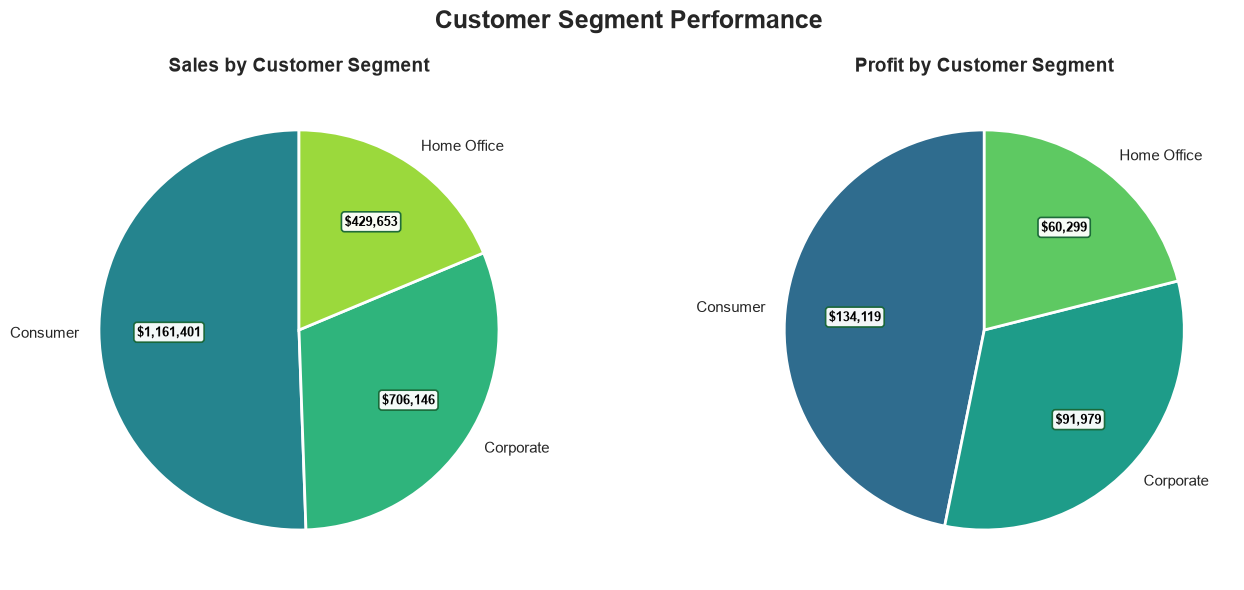

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

data = segment_analysis.reset_index()

sales_colors = plt.cm.viridis(
    np.linspace(0.45, 0.85, len(data))
)

wedges1, texts1 = axes[0].pie(
    data["Sales"],
    labels=data["Segment"],
    colors=sales_colors,
    startangle=90,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=2
    )
)

axes[0].set_title(
    "Sales by Customer Segment",
    fontsize=14,
    fontweight="bold"
)

for wedge, value in zip(wedges1, data["Sales"]):

    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 0.65 * np.cos(np.radians(angle))
    y = 0.65 * np.sin(np.radians(angle))

    axes[0].text(
        x,
        y,
        f"${value:,.0f}",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="#166534",
            linewidth=1.2,
            alpha=0.95
        )
    )

profit_colors = plt.cm.viridis(
    np.linspace(0.35, 0.75, len(data))
)

wedges2, texts2 = axes[1].pie(
    data["Profit"],
    labels=data["Segment"],
    colors=profit_colors,
    startangle=90,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=2
    )
)
axes[1].set_title(
    "Profit by Customer Segment",
    fontsize=14,
    fontweight="bold"
)

for wedge, value in zip(wedges2, data["Profit"]):

    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 0.65 * np.cos(np.radians(angle))
    y = 0.65 * np.sin(np.radians(angle))

    axes[1].text(
        x,
        y,
        f"${value:,.0f}",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="#166534",
            linewidth=1.2,
            alpha=0.95
        )
    )
fig.suptitle(
    "Customer Segment Performance",
    fontsize=18,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

In [52]:
cust = (
    clean_df.groupby("Customer ID")
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"),
         Orders=("Order ID", "nunique"))
    .sort_values("Profit")
)
print("Customers:", len(cust))
print("Share of profit from top 10% customers:",
      cust["Profit"].nlargest(int(len(cust)*0.10)).sum() / cust["Profit"].sum())
print("Customers with negative total profit:", (cust["Profit"] < 0).sum())


Customers: 793
Share of profit from top 10% customers: 0.5728994625225885
Customers with negative total profit: 155


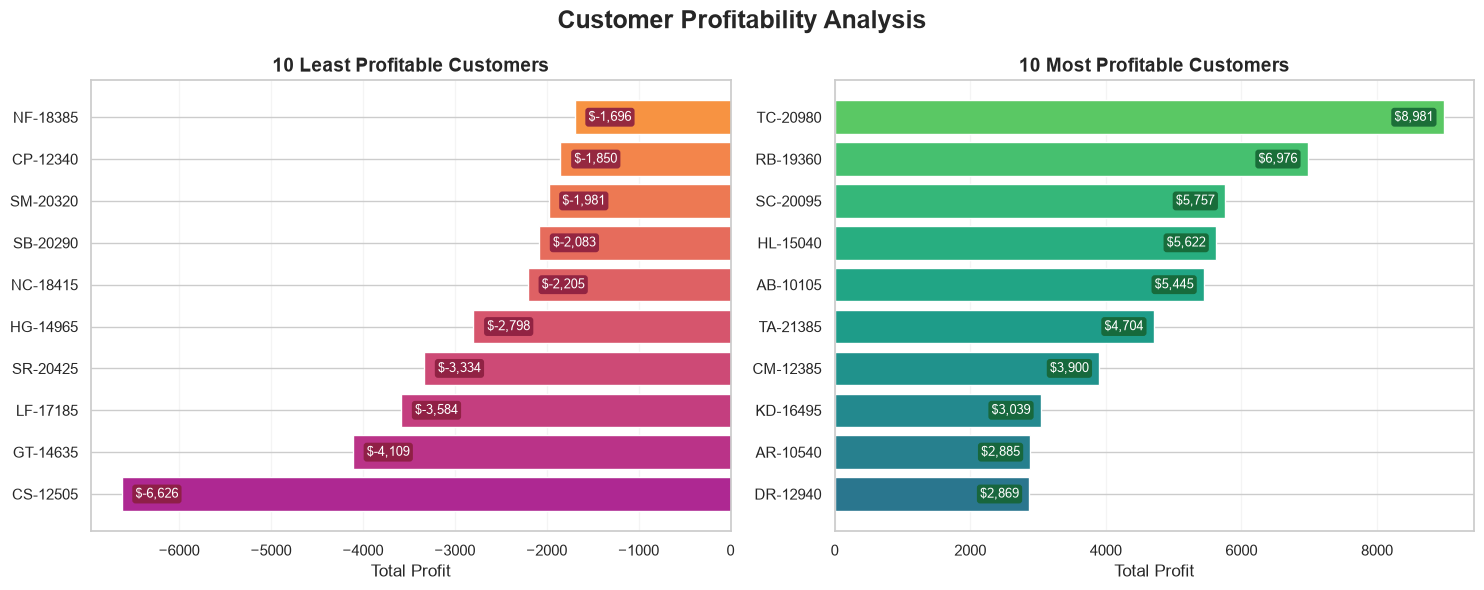

In [53]:
worst = cust.head(10).sort_values("Profit")
best = cust.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(
    worst.index.astype(str),
    worst["Profit"],
    color=plt.cm.plasma(range(100, 200, 10))
)

axes[0].set_title(
    "10 Least Profitable Customers",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_xlabel("Total Profit")
axes[0].grid(axis="x", alpha=0.2)

for i, value in enumerate(worst["Profit"]):
    axes[0].text(
        value + 150,
        i,
        f"${value:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="#8B1E3F",
            edgecolor="none",
            alpha=0.9
        )
    )

axes[1].barh(
    best.index.astype(str),
    best["Profit"],
    color=plt.cm.viridis(range(100, 200, 10))
)

axes[1].set_title(
    "10 Most Profitable Customers",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_xlabel("Total Profit")
axes[1].grid(axis="x", alpha=0.2)

for i, value in enumerate(best["Profit"]):
    axes[1].text(
        value - 150,             
        i,
        f"${value:,.0f}",
        va="center",
        ha="right",
        fontsize=9,
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="#166534",
            edgecolor="none",
            alpha=0.9
        )
    )


fig.suptitle(
    "Customer Profitability Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Consumer is largest; margins are similar across segments. Segment is not where the money is leaking.

# 9.KPI Dashboard

In [54]:
def calculate_kpis(dataframe):

    total_sales = dataframe["Sales"].sum()
    total_profit = dataframe["Profit"].sum()

    kpis = {
        "Total Sales": total_sales,
        "Total Profit": total_profit,
        "Profit Margin %": (
            total_profit / total_sales * 100
            if total_sales != 0 else np.nan
        ),
        "Total Quantity": dataframe["Quantity"].sum(),
        "Total Orders": dataframe["Order ID"].nunique(),
        "Total Customers": dataframe["Customer ID"].nunique(),
        "Average Order Value": (
            dataframe.groupby("Order ID")["Sales"].sum().mean()
        ),
        "Average Shipping Duration": (
            dataframe["Shipping Duration"].mean()
        ),
        "Average Discount": dataframe["Discount"].mean(),
        "Loss-Making Transactions": (
            (dataframe["Profit"] < 0).sum()
        )
    }

    return pd.Series(kpis, name="Value")

In [55]:
kpis = calculate_kpis(clean_df)
display(kpis.to_frame().round(2))

,Value
Total Sales,"2,297,200.86"
Total Profit,"286,397.02"
Profit Margin %,12.47
Total Quantity,"37,873.00"
Total Orders,"5,009.00"
Total Customers,793.00
Average Order Value,458.61
Average Shipping Duration,3.96
Average Discount,0.16
Loss-Making Transactions,"1,871.00"


In [56]:
def plot_kpi_dashboard(kpi_series):

    dashboard_items = [
        ("TOTAL SALES", f"${kpi_series['Total Sales']:,.0f}"),
        ("TOTAL PROFIT", f"${kpi_series['Total Profit']:,.0f}"),
        ("PROFIT MARGIN", f"{kpi_series['Profit Margin %']:.2f}%"),
        ("TOTAL ORDERS", f"{kpi_series['Total Orders']:,.0f}"),
        ("CUSTOMERS", f"{kpi_series['Total Customers']:,.0f}"),
        ("LOSS TRANSACTIONS", f"{kpi_series['Loss-Making Transactions']:,.0f}")
    ]

    fig, axes = plt.subplots(
        2, 3,
        figsize=(15, 7)
    )

    fig.patch.set_facecolor("#0B132B")

    for i, (ax, (title, value)) in enumerate(
        zip(axes.flat, dashboard_items)
    ):

        ax.set_facecolor("#16213E")

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("#263859")
            spine.set_linewidth(1.5)

        ax.set_xticks([])
        ax.set_yticks([])

        ax.plot(
            [0.08, 0.92],
            [0.15, 0.15],
            transform=ax.transAxes,
            linewidth=3,
            color="#D4AF37"
        )

        ax.text(
            0.08,
            0.63,
            value,
            transform=ax.transAxes,
            fontsize=24,
            fontweight="bold",
            color="#FFFFFF",
            ha="left"
        )

        ax.text(
            0.08,
            0.34,
            title,
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            color="#AAB4C8",
            ha="left"
        )
    fig.suptitle(
            "SUPERSTORE 2016-2019",
            fontsize=22,
            fontweight="bold",
            color="#D4AF37",
            y=0.99
        )
  

    fig.text(
        0.5,
        0.90,
        
        "Executive KPI Dashboard",
        fontsize=22,
        fontweight="bold",
        color="#FFFFFF",
        ha="center"
    )

    plt.subplots_adjust(
        top=0.82,
        bottom=0.08,
        left=0.05,
        right=0.95,
        wspace=0.18,
        hspace=0.28
    )

    plt.show()

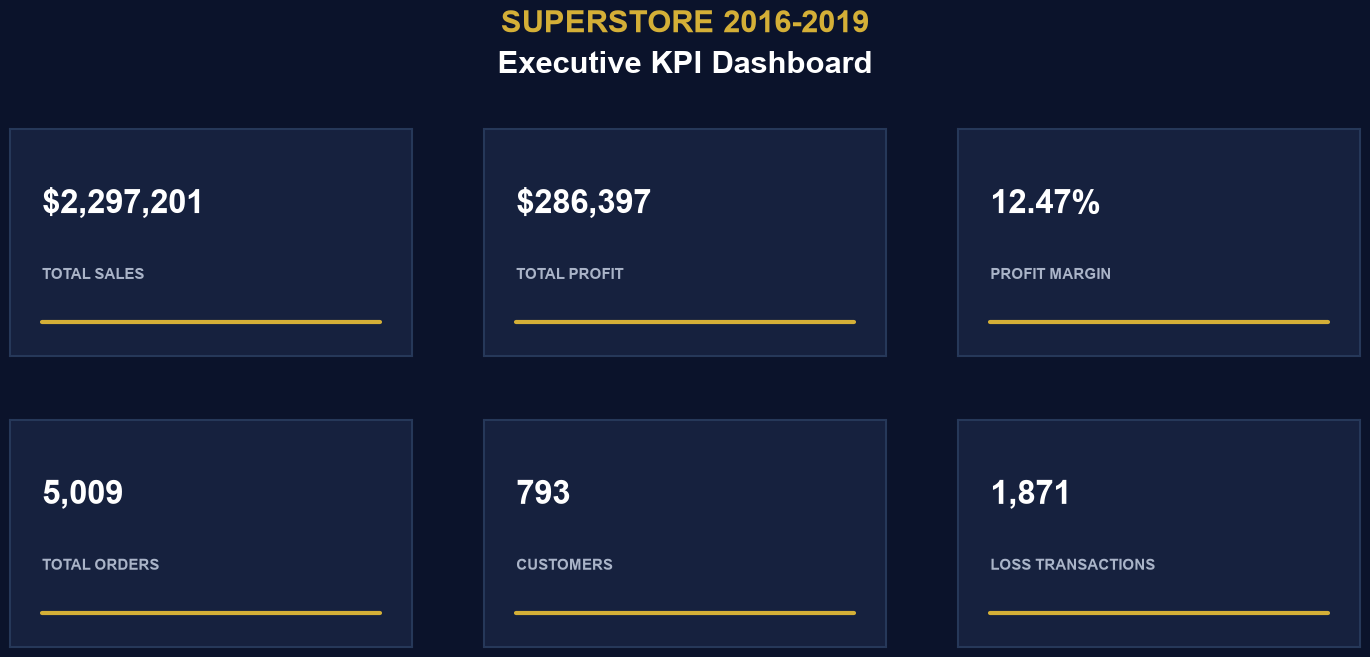

In [57]:
plot_kpi_dashboard(kpis)

In [58]:
shipping_mode = (
    clean_df
    .groupby("Ship Mode")
    .agg(
        Orders=("Order ID", "nunique"),
        Average_Shipping_Days=("Shipping Duration", "mean"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Average_Shipping_Days")
)

display(shipping_mode.round(2))

,Orders,Average_Shipping_Days,Sales,Profit
Ship Mode,,,,
Same Day,264,0.04,"128,363.12","15,891.76"
First Class,787,2.18,"351,428.42","48,969.84"
Second Class,964,3.24,"459,193.57","57,446.64"
Standard Class,2994,5.01,"1,358,215.74","164,088.79"


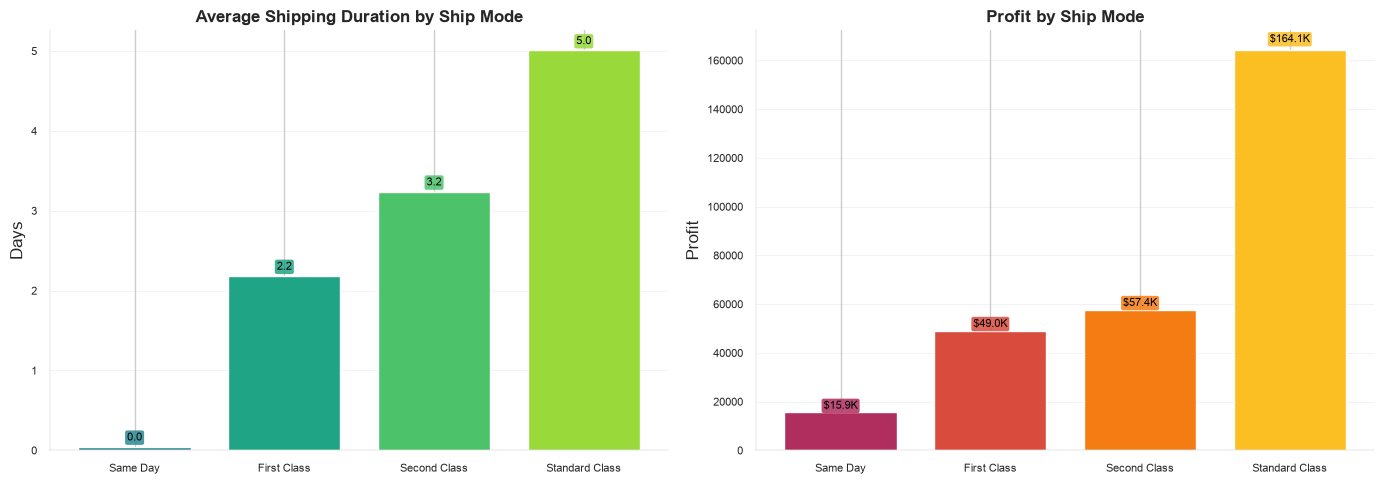

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shipping_data = shipping_mode.reset_index()
colors_shipping = ["#2A8893", "#20A486", "#4CC26B", "#9AD93A"]
colors_profit = ["#B02E5E", "#D94B3D", "#F57C12", "#FBBF24"]

bars1 = axes[0].bar(
    shipping_data["Ship Mode"],
    shipping_data["Average_Shipping_Days"],
    color=colors_shipping,
    width=0.75
)

axes[0].set_title(
    "Average Shipping Duration by Ship Mode",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Days")

# Labels
for bar in bars1:
    value = bar.get_height()

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor=bar.get_facecolor(),
            edgecolor="none",
            alpha=0.85
        )
    )

bars2 = axes[1].bar(
    shipping_data["Ship Mode"],
    shipping_data["Profit"],
    color=colors_profit,
    width=0.75
)

axes[1].set_title(
    "Profit by Ship Mode",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel("")
axes[1].set_ylabel("Profit")

# Labels
for bar in bars2:
    value = bar.get_height()

    if abs(value) >= 1_000_000:
        label = f"${value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        label = f"${value / 1_000:.1f}K"
    else:
        label = f"${value:.0f}"

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + abs(value) * 0.015,
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor=bar.get_facecolor(),
            edgecolor="none",
            alpha=0.85
        )
    )

for ax in axes:

  
    ax.grid(
        axis="y",
        linestyle="-",
        linewidth=0.7,
        alpha=0.25
    )

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.25)
    ax.spines["bottom"].set_alpha(0.25)

    ax.tick_params(
        axis="both",
        labelsize=8
    )

plt.tight_layout()
plt.show()

Standard Class is slowest and still the profit pool because of volume. Shipping speed is not the profit problem.

# 10.Automated Executive Summary

In [60]:
def generate_executive_summary(dataframe):

    region = (
        dataframe
        .groupby("Region")
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum")
        )
    )

    region["Profit Margin %"] = (
        region["Profit"] / region["Sales"] * 100
    )

    best_region = region["Profit"].idxmax()
    weakest_region = region["Profit Margin %"].idxmin()

    category = (
        dataframe
        .groupby("Category")
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum")
        )
    )

    category["Profit Margin %"] = (
        category["Profit"] / category["Sales"] * 100
    )

    best_category = category["Profit"].idxmax()
    weakest_category = category["Profit Margin %"].idxmin()

    annual = (
        dataframe
        .groupby("Order Year")
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum")
        )
    )

    first_year = annual.index.min()
    last_year = annual.index.max()
    sales_growth = (
        (annual.loc[last_year, "Sales"] /annual.loc[first_year, "Sales"]) - 1)* 100

    discount_corr = (
        dataframe["Discount"]
        .corr(dataframe["Profit Margin"])
    )

    loss_rate = (
        (dataframe["Profit"] < 0).mean() * 100
    )

    print("=" * 70)
    print("AUTOMATED EXECUTIVE SUMMARY")
    print("=" * 70)

    print(
        f"\n1. Overall Performance\n"
        f"   Total sales reached "
        f"${dataframe['Sales'].sum():,.2f}, generating "
        f"${dataframe['Profit'].sum():,.2f} in profit."
    )

    print(
        f"\n2. Growth\n"
        f"   Sales changed by {sales_growth:.2f}% "
        f"between {first_year} and {last_year}."
    )

    print(
        f"\n3. Regional Performance\n"
        f"   {best_region} is the most profitable region, "
        f"while {weakest_region} has the lowest profit margin."
    )

    print(
        f"\n4. Category Performance\n"
        f"   {best_category} is the most profitable category, "
        f"while {weakest_category} has the lowest profit margin."
    )

    print(
        f"\n5. Discount & Profitability\n"
        f"   Discount has a correlation of "
        f"{discount_corr:.2f} with Profit Margin."
    )

    print(
        f"\n6. Loss Exposure\n"
        f"   {loss_rate:.2f}% of transactions are loss-making."
    )

    print("\n" + "=" * 70)

In [61]:
generate_executive_summary(clean_df)

AUTOMATED EXECUTIVE SUMMARY

1. Overall Performance
   Total sales reached $2,297,200.86, generating $286,397.02 in profit.

2. Growth
   Sales changed by 51.41% between 2016 and 2019.

3. Regional Performance
   West is the most profitable region, while Central has the lowest profit margin.

4. Category Performance
   Technology is the most profitable category, while Furniture has the lowest profit margin.

5. Discount & Profitability
   Discount has a correlation of -0.86 with Profit Margin.

6. Loss Exposure
   18.72% of transactions are loss-making.



# 11.Object-Oriented Analysis

In [62]:
class SuperstoreAnalyzer:
  
    def __init__(self, dataframe):
        if not isinstance(dataframe, pd.DataFrame):
            raise TypeError("dataframe must be a pandas DataFrame")

        self.df = dataframe.copy()

    def calculate_kpis(self):
        return calculate_kpis(self.df)

    def regional_analysis(self):
        result = (
            self.df
            .groupby("Region")
            .agg(
                Sales=("Sales", "sum"),
                Profit=("Profit", "sum"),
                Orders=("Order ID", "nunique")
            )
        )

        result["Profit Margin %"] = (
            result["Profit"] / result["Sales"] * 100
        )

        return result.sort_values(
            "Profit",
            ascending=False
        )

    def category_analysis(self):
        result = (
            self.df
            .groupby("Category")
            .agg(
                Sales=("Sales", "sum"),
                Profit=("Profit", "sum"),
                Quantity=("Quantity", "sum"),
                Orders=("Order ID", "nunique")
            )
        )

        result["Profit Margin %"] = (
            result["Profit"] / result["Sales"] * 100
        )

        return result.sort_values(
            "Profit",
            ascending=False
        )

    def loss_analysis(self):
        loss_df = self.df[
            self.df["Profit"] < 0
        ]

        result = (
            loss_df
            .groupby("Category")
            .agg(
                Transactions=("Order ID", "count"),
                Total_Loss=("Profit", "sum"),
                Avg_Loss=("Profit", "mean")
            )
            .sort_values("Total_Loss")
        )

        return result

    def correlation_analysis(self):
        numeric_cols = [
            "Sales",
            "Quantity",
            "Discount",
            "Profit",
            "Shipping Duration",
            "Profit Margin"
        ]

        return self.df[numeric_cols].corr()

    def executive_summary(self):
        generate_executive_summary(self.df)

    def full_report(self):
        return {
            "kpis": self.calculate_kpis(),
            "regional_analysis": self.regional_analysis(),
            "category_analysis": self.category_analysis(),
            "loss_analysis": self.loss_analysis(),
            "correlation": self.correlation_analysis()
        }

In [63]:
analyzer = SuperstoreAnalyzer(clean_df)
print("SuperstoreAnalyzer initialized successfully.")

SuperstoreAnalyzer initialized successfully.


# 12.Exception Handling

In [64]:
def run_analysis_pipeline(dataframe):
    
    try:
        if dataframe.empty:
            raise ValueError("The dataset is empty.")
        required_columns = [
            "Sales",
            "Quantity",
            "Discount",
            "Profit",
            "Order ID",
            "Customer ID",
            "Order Date",
            "Ship Date"
        ]
        missing_columns = [
            column
            for column in required_columns
            if column not in dataframe.columns
        ]
        if missing_columns:
            raise ValueError(
                f"Missing required columns: {missing_columns}"
            )
        analyzer = SuperstoreAnalyzer(dataframe)
        report = analyzer.full_report()
        print("Analysis pipeline completed successfully.")
        return report

    except Exception as error:
        print(f"Pipeline error: {error}")
        return None

In [65]:
report = run_analysis_pipeline(clean_df)

Analysis pipeline completed successfully.


# 13.Automated Export

In [66]:
OUTPUT_DIR = Path("superstore_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: C:\Projects\superstore_outputs


In [67]:
clean_df.to_csv(OUTPUT_DIR / "superstore_cleaned.csv",index=False)
print("Cleaned dataset exported.")
kpis.to_frame().to_csv(OUTPUT_DIR / "kpi_summary.csv")
print("KPI summary exported.")
analyzer.regional_analysis().to_csv(OUTPUT_DIR / "regional_analysis.csv")
print("Regional analysis exported.")
analyzer.category_analysis().to_csv(OUTPUT_DIR / "category_analysis.csv")
print("Category analysis exported.")
analyzer.loss_analysis().to_csv(OUTPUT_DIR / "loss_analysis.csv")
print("Loss analysis exported.")

Cleaned dataset exported.
KPI summary exported.
Regional analysis exported.
Category analysis exported.
Loss analysis exported.


# 14.Final Business Recommendations

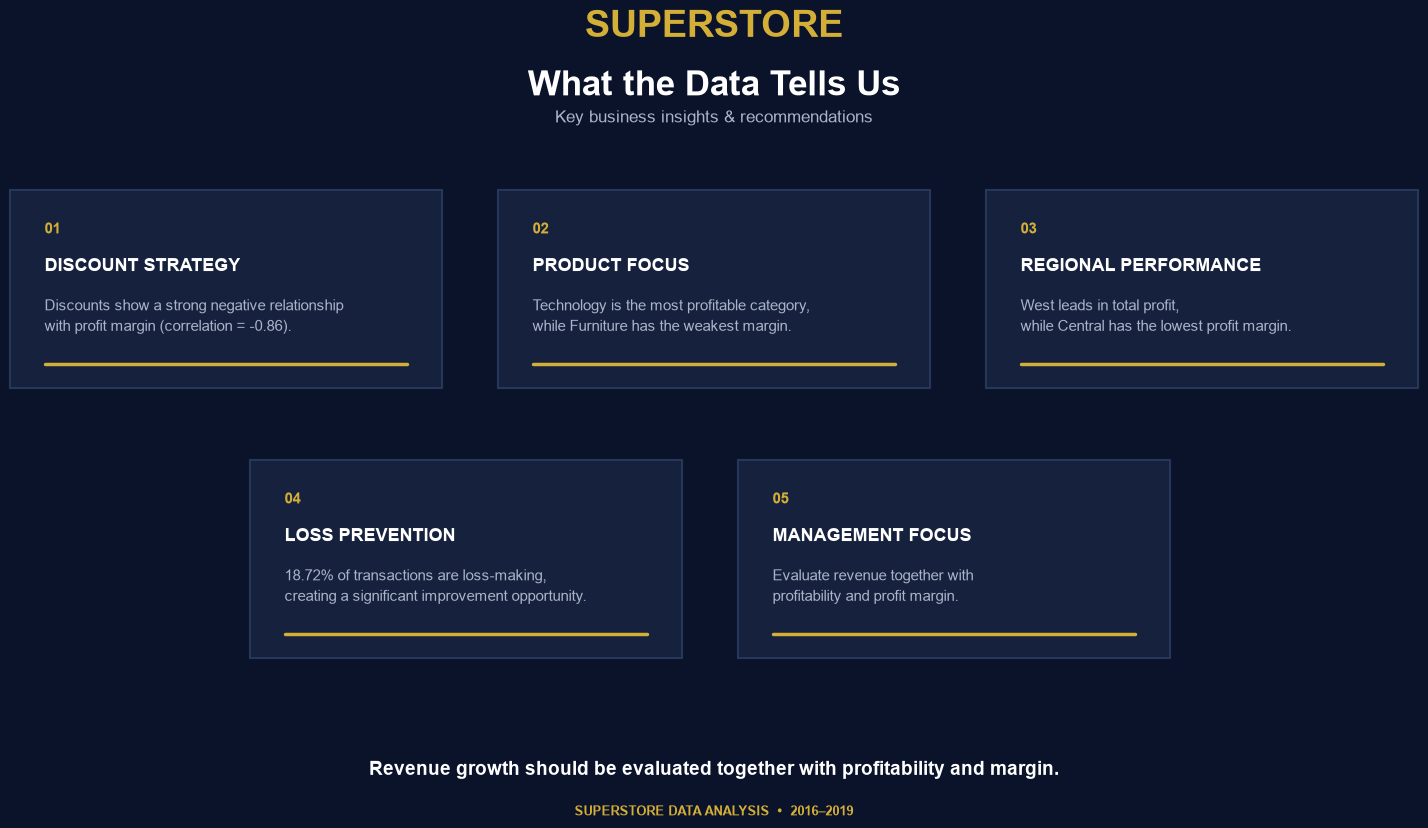

In [68]:
from matplotlib.patches import FancyBboxPatch

recommendations = [

    (
        "01",
        "DISCOUNT STRATEGY",
        "Discounts show a strong negative relationship\n"
        "with profit margin (correlation = -0.86)."
    ),

    (
        "02",
        "PRODUCT FOCUS",
        "Technology is the most profitable category,\n"
        "while Furniture has the weakest margin."
    ),

    (
        "03",
        "REGIONAL PERFORMANCE",
        "West leads in total profit,\n"
        "while Central has the lowest profit margin."
    ),

    (
        "04",
        "LOSS PREVENTION",
        "18.72% of transactions are loss-making,\n"
        "creating a significant improvement opportunity."
    ),

    (
        "05",
        "MANAGEMENT FOCUS",
        "Evaluate revenue together with\n"
        "profitability and profit margin."
    )
]

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor("#0B132B")

fig.text(
    0.5,
    0.94,
    "SUPERSTORE",
    fontsize=27,
    fontweight="bold",
    color="#D4AF37"
,ha="center")

fig.text(
    0.5,
    0.875,
    "What the Data Tells Us",
    fontsize=25,
    fontweight="bold",
    color="#FFFFFF",
    ha="center"
)

fig.text(
    0.5,
    0.845,
    "Key business insights & recommendations",
    fontsize=12,
    color="#AAB4C8",
    ha="center"
)

positions = [

    (0.06, 0.55, 0.27, 0.22),
    (0.365, 0.55, 0.27, 0.22),
    (0.67, 0.55, 0.27, 0.22),

    (0.21, 0.25, 0.27, 0.22),
    (0.515, 0.25, 0.27, 0.22)

]

for (number, title, text), position in zip(
    recommendations,
    positions
):
    ax = fig.add_axes(position)
    ax.set_facecolor("#16213E")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():

        spine.set_visible(True)
        spine.set_color("#263859")
        spine.set_linewidth(1.5)

    ax.plot(
        [0.08, 0.92],
        [0.12, 0.12],
        transform=ax.transAxes,
        color="#D4AF37",
        linewidth=2.5
    )

    ax.text(
        0.08,
        0.78,
        number,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        color="#D4AF37"
    )

    ax.text(
        0.08,
        0.59,
        title,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        color="#FFFFFF"
    )

    ax.text(
        0.08,
        0.36,
        text,
        transform=ax.transAxes,
        fontsize=10.5,
        color="#AAB4C8",
        va="center",
        linespacing=1.5
    )

fig.text(
    0.5,
    0.12,
    "Revenue growth should be evaluated together with profitability and margin.",
    ha="center",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF"
)

fig.text(
    0.5,
    0.075,
    "SUPERSTORE DATA ANALYSIS  •  2016–2019",
    ha="center",
    fontsize=9,
    fontweight="bold",
    color="#D4AF37"
)


plt.show()

# 15. Project Validation

In [69]:
def validate_project(dataframe):

    required_features = [
        "Shipping Duration",
        "Profit Margin",
        "Order Year",
        "Order Month",
        "Order Quarter",
        "Sales Performance Category"
    ]

    checks = {
        "Dataset not empty":
            not dataframe.empty,

        "Expected row count":
            len(dataframe) == 9994,

        "No duplicate rows":
            dataframe.duplicated().sum() == 0,

        "Row ID unique":
            dataframe["Row ID"].is_unique,

        "Dates valid":
            (
                dataframe["Ship Date"] >=
                dataframe["Order Date"]
            ).all(),

        "Sales numeric":
            pd.api.types.is_numeric_dtype(
                dataframe["Sales"]
            ),

        "Profit numeric":
            pd.api.types.is_numeric_dtype(
                dataframe["Profit"]
            ),

        "Required engineered features":
            all(
                feature in dataframe.columns
                for feature in required_features
            )
    }

    return pd.DataFrame(
        list(checks.items()),
        columns=["Validation Check", "Passed"]
    )


final_validation = validate_project(clean_df)

display(final_validation)

print(
    f"\nPassed: "
    f"{final_validation['Passed'].sum()}/"
    f"{len(final_validation)}"
)

,Validation Check,Passed
0,Dataset not empty,True
1,Expected row count,True
2,No duplicate rows,True
3,Row ID unique,True
4,Dates valid,True
5,Sales numeric,True
6,Profit numeric,True
7,Required engineered features,True



Passed: 8/8
